A neural image recovery of the temperature structure of HD163296
---


In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import os, sys
import matplotlib
from pathlib import Path
from ruamel.yaml import YAML
from tqdm.auto import tqdm
from gofish import imagecube
from mpl_toolkits.axes_grid1 import make_axes_locatable
import emcee, corner
from collections import OrderedDict
import tensorboardX
from flax.training import checkpoints

os.environ['CUDA_VISIBLE_DEVICES'] = '4,5'

sys.path.insert(0, '../')
import visualization, sensor, grid, line_rte, parametric_disk, inference, network
from network import shard
from consts import *

/srv/tmp/aviad/miniconda3/envs/jax/lib/python3.12/site-packages/gofish/gofish.py:3535: SyntaxWarning: invalid escape sequence '\-'
  """


In [2]:
def render_cube(ray_coords, pixel_area, disk, nd_co, temperature, velocity_az, bbox, freqs, nu0):
    ray_coords_sph = grid.cartesian_to_spherical(ray_coords)
    ray_coords_polar = grid.spherical_to_zr(ray_coords_sph)
    
    # Interpolate dataset along the ray coordinates
    gas_nd = grid.interpolate_scalar(nd_co, ray_coords_polar, bbox)
    gas_t  = grid.interpolate_scalar(temperature, ray_coords_polar, bbox, cval=1e-10)
    gas_v_az = grid.interpolate_scalar(velocity_az, ray_coords_polar, bbox)
    gas_v = parametric_disk.azimuthal_velocity(ray_coords, gas_v_az)
    
    # Einstein coefficient for spontaneous emission from level u to level d
    energy_levels, radiative_transitions = line_rte.load_molecular_tables(path=disk.molecule_table)
    _, a_ud, b_ud, b_du = line_rte.einstein_coefficients(energy_levels, radiative_transitions, transition=disk.transition)
    n_up, n_dn = line_rte.n_up_down(gas_nd, gas_t, energy_levels, radiative_transitions, transition=disk.transition)

    alpha_tot = line_rte.alpha_total_co(disk.v_turb, gas_t)

    # print('computing spectral cube for a total of {} frequencies'.format(freqs.size))
    images = line_rte.compute_spectral_cube_pmap(shard(freqs), gas_v, alpha_tot, n_up, n_dn, a_ud, b_ud, b_du, ray_coords, obs_dir, nu0, pixel_area)
    images = np.nan_to_num(images).reshape(freqs.size, *ray_coords.shape[:2])
    return images

def intensity_to_nchw(intensity, vmin=None, vmax=None, cmap='viridis', gamma=0.5):
    cm = plt.get_cmap(cmap)
    if vmin is None: vmin = np.min(intensity)
    if vmax is None: vmax = np.max(intensity)
    norm_images = np.flip(( (intensity - vmin) / (vmax - vmin) )**gamma, axis=-2)
    if intensity.ndim == 2:
        nchw_images = np.moveaxis(cm(norm_images)[...,:3], (0, 1, 2), (1, 2, 0))
    elif intensity.ndim == 3:
        nchw_images = np.moveaxis(cm(norm_images)[...,:3], (0, 1, 2, 3), (0, 2, 3, 1))
    return nchw_images

In [3]:
""" 
Notes
-----
isotop_abundance: 12c16o=1; 13c16o=1/69; 12c18o=1/557;
vlsr has a slight depedency on isotop: 12c16o=5.76km/s; 13c16o=5.77km/s; 12c18o=5.76km/s;
see https://iopscience.iop.org/article/10.3847/1538-4365/ac1438/pdf
"""
fov_as = 10.0                 # arcsecs
velocity_range = (2000, 10000) # m/s

#data_path = '../data/alma_highres/HD_163296_CO_220GHz.0.2arcsec.image.fits'
#vlsr = 5760   # m/s
#isotop_abundance = 1

data_path = '../data/alma_highres/HD163296_13CO_beam0.20_100ms_3sigma.clean.image.cutout.fits'
vlsr = 5770   # m/s
isotop_abundance = 1/69
# 
# data_path = '../data/alma_highres/HD163296_C18O_beam0.20_100ms_3sigma.clean.image.cutout.fits'
# vlsr = 5750   # m/s
# isotop_abundance = 1/557

data_cube = imagecube(data_path, FOV=fov_as, velocity_range=velocity_range)
freqs = data_cube.velocity_to_restframe_frequency(vlsr=vlsr)
velocities = data_cube.velax
data = data_cube.data
x_sky, y_sky = np.meshgrid(data_cube.xaxis, data_cube.yaxis, indexing='xy')
nu0 = data_cube.nu0
npix = data_cube.nxpix
width_kms = (velocities[-1] - velocities[0]) / 1000.0
delta_v_ms = velocities[1] - velocities[0]
num_freqs = len(freqs)
data_dir = Path(data_path).parent
print('velocity resolution: {} m/s'.format(delta_v_ms))

beam = data_cube.beams_per_pix * sensor.beam(data_cube.dpix, data_cube.bmaj, data_cube.bmin, data_cube.bpa)

velocity resolution: 99.99999997745999 m/s


In [71]:
from scipy import signal
scale = 3
hann = np.hanning(scale)[:,None,None]
filtered = signal.convolve(images, hann, mode='same') / np.sum(hann)
images_blurred = sensor.fftconvolve_vmap(images, beam)

In [88]:
error = []
scales = range(3,12,2)
for scale in tqdm(scales):
    hann = np.hanning(scale)[:,None,None]
    filtered = signal.convolve(images, hann, mode='same') / np.sum(hann)
    images_blurred = sensor.fftconvolve_vmap(filtered, beam)
    error.append(np.abs(data - images_blurred).mean())

  0%|          | 0/5 [00:00<?, ?it/s]

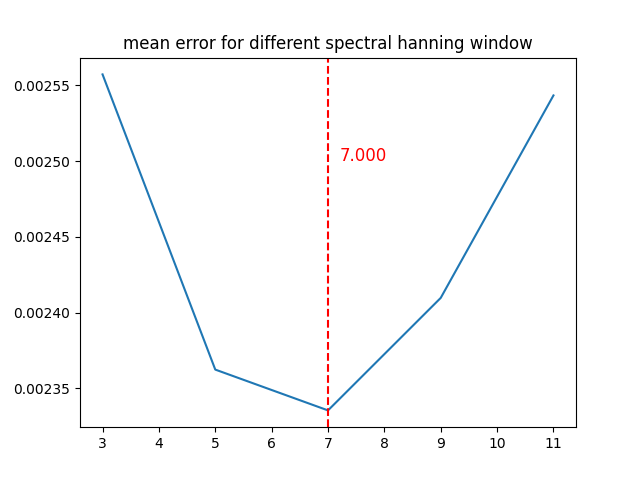

In [89]:
%matplotlib widget
plt.figure()
plt.plot(scales, error)
plt.text(scales[np.argmin(error)]*1.03, 0.0025, '{:2.3f}'.format(scales[np.argmin(error)]), fontsize=12, color='r')
plt.title('mean error for different spectral hanning window')
plt.axvline(scales[np.argmin(error)], color='r', linestyle='--')
plt.show()

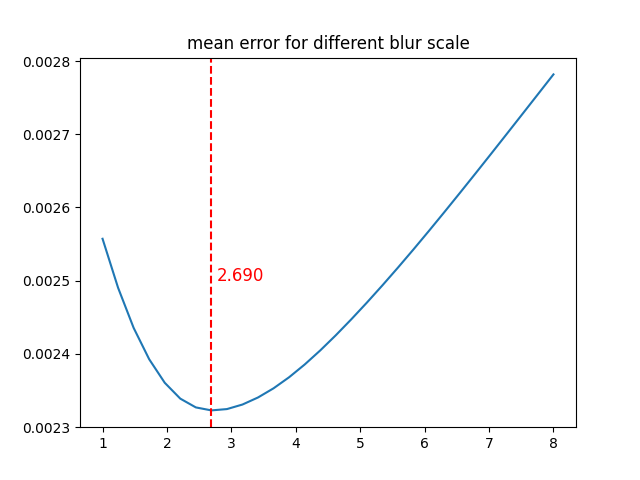

In [64]:
"""
error = []
scales = np.linspace(1.0,8.0, 30)
for scale in tqdm(scales):
    beam = data_cube.beams_per_pix * sensor.beam(data_cube.dpix, data_cube.bmaj, data_cube.bmin, data_cube.bpa, scale=scale)
    images_blurred = sensor.fftconvolve_vmap(images, beam)
    error.append(np.abs(data - images_blurred).mean())

%matplotlib widget
plt.figure()
plt.plot(scales, error)
plt.text(scales[np.argmin(error)]*1.03, 0.0025, '{:2.3f}'.format(scales[np.argmin(error)]), fontsize=12, color='r')
plt.title('mean error for different blur scale')
plt.axvline(scales[np.argmin(error)], color='r', linestyle='--')
plt.show()
"""

# Fiducial model

In [4]:
disk = parametric_disk.DiskFlaherty(
    name='HD163296_CO(2-1)',
    q=-0.27,
    q_in=-0.57,
    r_break=70,
    log_r_c=2.3,
    v_turb=0.06,
    T_atm1=87.0,
    gamma=1.0,
    T_mid1=17.8,
    M_star=2.3*M_sun,
    r_in=11.0,
    M_gas=0.09*M_sun,
    co_abundance=1e-4 * isotop_abundance,
    N_dissoc=0.79*1.59e21,
    N_desorp=-np.inf,
    freezeout=19.0,
    r_scale=150.0,
    z_q0=70.0,
    delta=1,
    transition=2,
    m_mol=2.37*m_h,
    molecule_table='../molecular_tables/molecule_12c16o.inp',
)

resolution = 500
z_min, z_max = 0, 200
r_min, r_max = disk.r_in, 800
z_disk, r_disk = jnp.meshgrid(jnp.linspace(z_min, z_max, resolution), jnp.linspace(r_min, r_max, resolution), indexing='ij')

temperature = disk.temperature_profile(z_disk, r_disk)
nd_h2 = parametric_disk.number_density_profile(z_disk, r_disk, temperature, disk.gamma, disk.r_in, 10**disk.log_r_c, disk.M_gas, disk.M_star, disk.m_mol)
velocity_az = disk.velocity(z_disk, r_disk, nd_h2, temperature)

# Compute the column integrated density N(h2) (units of 1/cm^2)
N_h2 = parametric_disk.surface_density(z_disk, nd_h2)
sigma_h2 = N_h2 * m_h

# Compute the relative abundance of co
abundance_co = disk.co_abundance_profile(N_h2, temperature)
nd_co = abundance_co * nd_h2

In [5]:
projection = sensor.PinholeProjection(
    name=disk.name,
    x_sky=x_sky,
    y_sky=y_sky,
    distance=122.0, 
    nray=100,
    incl=47.5,
    phi=0.0,
    posang=312.0,
    z_width=2*z_max,
    freqs=freqs
)
# Bounding box for interpolations
bbox_disk = jnp.array([(au*z_min, au*z_max), (au*r_min, au*r_max)])

fov_rad =  fov_as*arcsec                                # field of view 
fov = 2 * projection.distance*pc * np.tan(fov_rad/2.0)  # gives ~1708 [au] for 14as
pixel_area = (fov/npix)**2
ray_coords, obs_dir = sensor.pinhole_disk_projection(
    projection.x_sky, projection.y_sky, projection.distance, projection.nray, 
    projection.incl, projection.phi, projection.posang, projection.z_width
)

# Render spectral cube and convolve with gaussian beam
images = render_cube(ray_coords, pixel_area, disk, nd_co, temperature, -velocity_az, bbox_disk, freqs, nu0)
images_blurred = sensor.fftconvolve_vmap(images, beam)

# Add spectral blurring?
# images_spectral_blur = signal.convolve(images, hann, mode='same') / np.sum(hann)
# images_blurred = sensor.fftconvolve_vmap(images_spectral_blur, beam)

interactive(children=(IntSlider(value=39, description='frame', max=79), Output()), _dom_classes=('widget-inter…

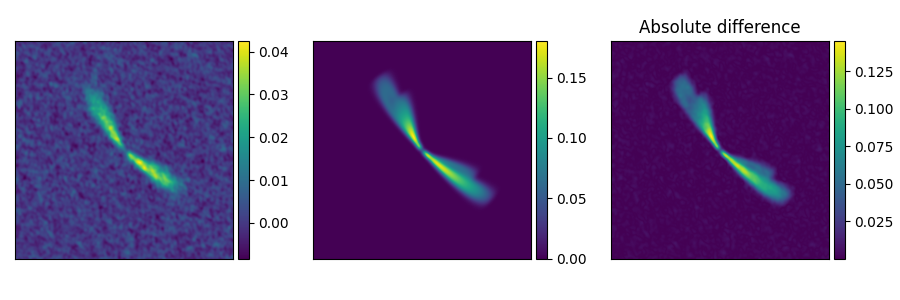

In [11]:
%matplotlib widget
visualization.slider_frame_comparison(data, images_blurred)

In [54]:
for v_bw in tqdm(v_bws[80:]):
    images_spectral_blurred = []
    for i in tqdm(range(num_freqs)):
        velax_10ms = np.linspace(velocities[i] - v_bw/2, velocities[i] + v_bw/2, num_integration)
        freqs_10ms = data_cube.velocity_to_restframe_frequency(velax=velax_10ms, vlsr=vlsr)
        images_10ms = render_cube(ray_coords, pixel_area, disk, nd_co, temperature, -velocity_az, bbox_disk, freqs_10ms, nu0)
        image_10ms = np.mean(images_10ms, axis=0)
        images_spectral_blurred.append(image_10ms)
    images_spectral_blurred = np.array(images_spectral_blurred)
    images_blurred_10ms = sensor.fftconvolve_vmap(images_spectral_blurred, beam)
    error.append(np.mean(np.abs(data - images_blurred_10ms)**2))

  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

...

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

In [44]:
error = []
num_integration = 40
v_bws = np.linspace(5, 400, 80)
for v_bw in tqdm(v_bws):
    images_spectral_blurred = []
    for i in tqdm(range(num_freqs)):
        velax_10ms = np.linspace(velocities[i] - v_bw/2, velocities[i] + v_bw/2, num_integration)
        freqs_10ms = data_cube.velocity_to_restframe_frequency(velax=velax_10ms, vlsr=vlsr)
        images_10ms = render_cube(ray_coords, pixel_area, disk, nd_co, temperature, -velocity_az, bbox_disk, freqs_10ms, nu0)
        image_10ms = np.mean(images_10ms, axis=0)
        images_spectral_blurred.append(image_10ms)
    images_spectral_blurred = np.array(images_spectral_blurred)
    images_blurred_10ms = sensor.fftconvolve_vmap(images_spectral_blurred, beam)
    error.append(np.mean(np.abs(data - images_blurred_10ms)**2))

  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

...

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

In [57]:
delta_v_ms * 7 

1399.9999998642988

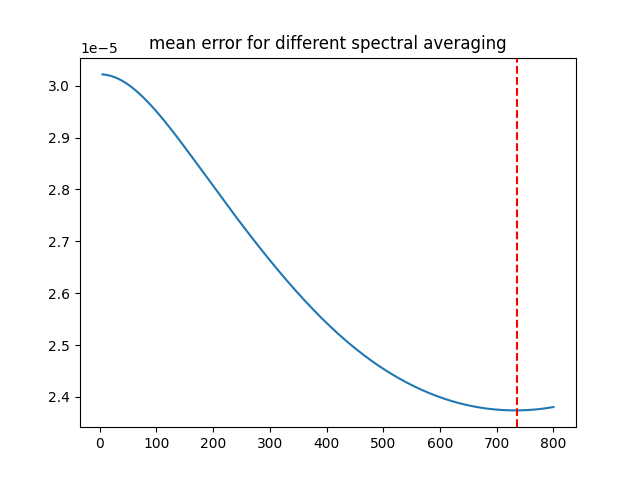

In [55]:
%matplotlib widget
plt.figure()
plt.plot(v_bws, error)
plt.text(v_bws[np.argmin(error)]*1.03, 0.0025, '{:2.3f}'.format(v_bws[np.argmin(error)]), fontsize=12, color='r')
plt.title('mean error for different spectral averaging')
plt.axvline(v_bws[np.argmin(error)], color='r', linestyle='--')
plt.show()

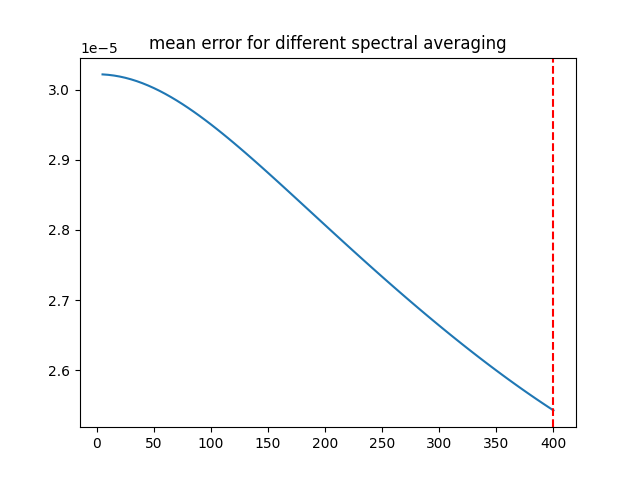

In [45]:
%matplotlib widget
plt.figure()
plt.plot(v_bws, error)
plt.text(v_bws[np.argmin(error)]*1.03, 0.0025, '{:2.3f}'.format(v_bws[np.argmin(error)]), fontsize=12, color='r')
plt.title('mean error for different spectral averaging')
plt.axvline(v_bws[np.argmin(error)], color='r', linestyle='--')
plt.show()

In [30]:
v_bw = 250.0 # m/s
num_integration = 10
images_spectral_blurred = []
for i in tqdm(range(num_freqs)):
    velax_10ms = np.linspace(velocities[i] - v_bw/2, velocities[i] + v_bw/2, num_integration)
    freqs_10ms = data_cube.velocity_to_restframe_frequency(velax=velax_10ms, vlsr=vlsr)
    images_10ms = render_cube(ray_coords, pixel_area, disk, nd_co, temperature, -velocity_az, bbox_disk, freqs_10ms, nu0)
    image_10ms = np.mean(images_10ms, axis=0)
    images_spectral_blurred.append(image_10ms)
images_spectral_blurred = np.array(images_spectral_blurred)
images_blurred_10ms = sensor.fftconvolve_vmap(images_spectral_blurred, beam)

  0%|          | 0/40 [00:00<?, ?it/s]

computing spectral cube for a total of 10 frequencies
computing spectral cube for a total of 10 frequencies
computing spectral cube for a total of 10 frequencies
computing spectral cube for a total of 10 frequencies
computing spectral cube for a total of 10 frequencies
computing spectral cube for a total of 10 frequencies
computing spectral cube for a total of 10 frequencies
computing spectral cube for a total of 10 frequencies
computing spectral cube for a total of 10 frequencies
computing spectral cube for a total of 10 frequencies
computing spectral cube for a total of 10 frequencies
computing spectral cube for a total of 10 frequencies
computing spectral cube for a total of 10 frequencies
computing spectral cube for a total of 10 frequencies
computing spectral cube for a total of 10 frequencies
computing spectral cube for a total of 10 frequencies
computing spectral cube for a total of 10 frequencies
computing spectral cube for a total of 10 frequencies
computing spectral cube for 

interactive(children=(IntSlider(value=19, description='frame', max=39), Output()), _dom_classes=('widget-inter…

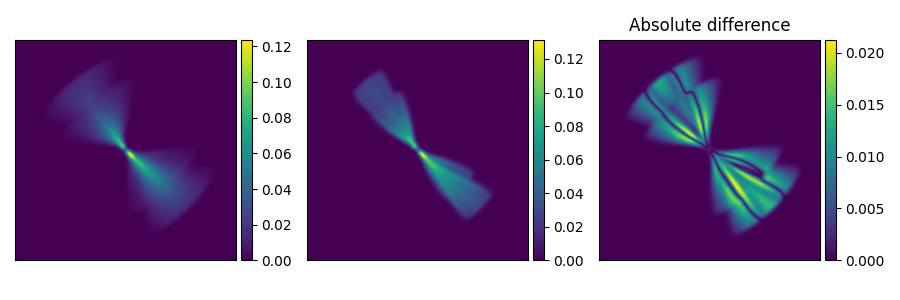

In [58]:
%matplotlib widget
visualization.slider_frame_comparison(images_blurred_10ms, images_blurred)

interactive(children=(IntSlider(value=19, description='frame', max=39), Output()), _dom_classes=('widget-inter…

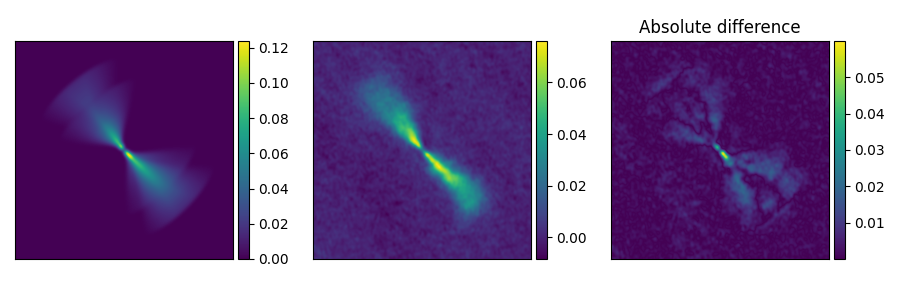

In [59]:
%matplotlib widget
visualization.slider_frame_comparison(images_blurred_10ms, data)

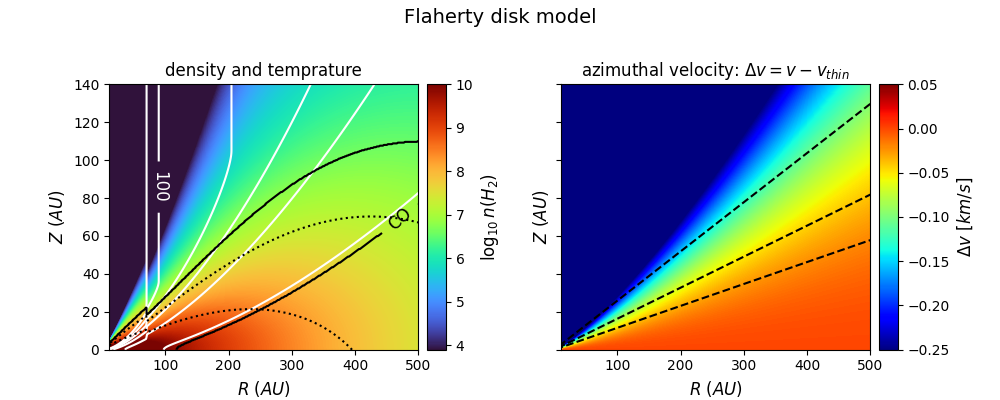

In [6]:
%matplotlib widget
fig, axes = plt.subplots(1,2, figsize=(10,4), sharey=True)
im = axes[0].imshow(np.log10(nd_h2), origin='lower', cmap='turbo', extent=[r_disk.min(), r_disk.max(), z_disk.min(), z_disk.max()], vmin=3.9, vmax=10, aspect=3);

divider = make_axes_locatable(axes[0])
cax = divider.append_axes('right', size='2%', pad=-3.)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(r'$\log_{10} n(H_2)$', fontsize=12)

levels = [20, 40, 60, 80, 100, 120]
cp = axes[0].contour(r_disk, z_disk, temperature, levels, colors='white')
axes[0].clabel(cp, levels, inline=1, fontsize=12);
cp = axes[0].contour(r_disk, z_disk, abundance_co, levels=[disk.co_abundance/2], colors='black')
axes[0].clabel(cp, levels=[disk.co_abundance/2], fmt='CO', inline=1, fontsize=12);
cp = axes[0].contour(r_disk, z_disk, sigma_h2, levels=[0.01, 0.1], colors='black', linestyles='dotted')


# Plot azimuthal velocity 
v_thin = np.sqrt(parametric_disk.vsq_keplerian_thin_disk(r_disk, disk.M_star))
delta_v = (velocity_az-v_thin)
im = axes[1].imshow(1e-5*delta_v, cmap='jet', vmin=-0.25, vmax=0.05, origin='lower', extent=[r_disk.min(), r_disk.max(), z_disk.min(), z_disk.max()], aspect=3)
divider = make_axes_locatable(axes[1])
cax = divider.append_axes('right', size='2%', pad=-3.)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(r'$\Delta v~[km/s]$', fontsize=12)
cp = axes[1].contour(r_disk, z_disk, 100*delta_v/velocity_az, levels=[-5, -2, -1], colors='black')
plt.clabel(cp, [-5, -2, -1], inline=True, fontsize=12, fmt=lambda x:'{:.0f} %'.format(x));

for ax in axes:
    ax.set_xlabel(r'$R~(AU)$', fontsize=12)
    ax.set_ylabel(r'$Z~(AU)$', fontsize=12)
    ax.set_xlim(r_disk.min(),500)
    ax.set_ylim(0,140)

axes[0].set_title('density and temprature')
axes[1].set_title(r'azimuthal velocity: $\Delta v = v-v_{thin}$')
plt.suptitle('Flaherty disk model', fontsize=14, y=0.98);
plt.tight_layout()
fig.subplots_adjust(left=-0.2, wspace=-0.3)

In [ ]:
# Save a gif/plot for the data cube for quick visualization
%matplotlib widget
fig, axes = plt.subplots(1,2,figsize=(8,4))
fig.suptitle(r'{} $\Delta v = {:2.1f} m/s$'.format(disk.name, delta_v_ms))
titles = [r'ALMA observations [Jy/beam]', r'Fiducial model (Flaherty) [Jy/beam]']
visualization.animate_movies_synced([data, np.array(images_blurred)], axes, vmin=[0,0], vmax=[0.5]*2, 
                                    titles=titles, cmaps='inferno', fps=5, 
                                    output=data_path.replace('fits', 'Flaherty.gif'))

# Neural temperature recovery

In [76]:
from jax import jit
from functools import partial
import flax
from datetime import datetime

@jax.tree_util.register_pytree_node_class
class NeuralTemperatureDisk(object):
    def __init__(self, z_disk, r_disk, bbox, pixel_area, ray_coords, ray_coords_polar, obs_dir, beam, 
                 energy_levels, radiative_transitions, disk):
        self.z_disk = z_disk
        self.r_disk = r_disk
        self.coords = jnp.stack((z_disk, r_disk), axis=-1).reshape(-1,2)
        self.bbox = bbox
        self.pixel_area = pixel_area
        self.ray_coords = ray_coords
        self.ray_coords_polar = ray_coords_polar
        self.obs_dir = obs_dir
        self.beam = beam
        self.energy_levels = energy_levels
        self.radiative_transitions = radiative_transitions
        self.disk = disk
        self.nu0, self.a_ud, self.b_ud, self.b_du = line_rte.einstein_coefficients(energy_levels, radiative_transitions, transition=disk.transition)
        self.disk_shape = z_disk.shape

    @partial(jit, static_argnums=(0, 2))
    def image_prediction(self, params, temp_fn, freqs):
            disk = self.disk
            temperature = temp_fn({'params': params}, self.coords).reshape(self.disk_shape)
        
            nd_h2 = parametric_disk.number_density_profile(
                self.z_disk, self.r_disk, temperature, disk.gamma, disk.r_in, 10**disk.log_r_c, disk.M_gas, disk.M_star, disk.m_mol
            )
            velocity_az = -disk.velocity(self.z_disk, self.r_disk, nd_h2, temperature)
            
            # Compute the column integrated density N(h2) (units of 1/cm^2)
            N_h2 = parametric_disk.surface_density(self.z_disk, nd_h2)
            
            # Compute the relative abundance of co
            abundance_co = disk.co_abundance_profile(N_h2, temperature)
            nd_co = abundance_co * nd_h2
            
            # Interpolate dataset along the ray coordinates
            gas_nd = grid.interpolate_scalar(nd_co, self.ray_coords_polar, self.bbox)
            gas_t  = grid.interpolate_scalar(temperature, self.ray_coords_polar, self.bbox, cval=1e-10)
            gas_v_az = grid.interpolate_scalar(velocity_az, self.ray_coords_polar, self.bbox)
            gas_v = parametric_disk.azimuthal_velocity(self.ray_coords, gas_v_az)
            
            # Einstein coefficient for spontaneous emission from level u to level d
            n_up, n_dn = line_rte.n_up_down(gas_nd, gas_t, self.energy_levels, self.radiative_transitions, transition=disk.transition)
            alpha_tot = line_rte.alpha_total_co(disk.v_turb, gas_t)
        
            model = jnp.nan_to_num(line_rte.compute_spectral_cube(
                freqs, gas_v, alpha_tot, n_up, n_dn, self.a_ud, self.b_ud, self.b_du, self.ray_coords, self.obs_dir, self.nu0, self.pixel_area
            ))
            model = sensor.fftconvolve_vmap(model, self.beam)
            return model
    
    def tree_flatten(self):
        children = (self.z_disk, self.r_disk, self.bbox, self.pixel_area, self.ray_coords, 
                    self.ray_coords_polar, self.obs_dir, self.beam, self.energy_levels, 
                    self.radiative_transitions, self.sigma, self.disk)
        aux_data = {}
        return (children, aux_data)

    @classmethod
    def tree_unflatten(cls, aux_data, children):
        return cls(*children, **aux_data) 


@partial(jit, static_argnums=(4,5))
def loss_fn(params, data, freqs, sigma, image_fn, temp_fn):
    model = image_fn(params, temp_fn, freqs)
    loss = jnp.mean(( (data-model)/sigma )**2)
    return loss
    
@partial(jit, static_argnums=(0, 1))
def gradient_step(loss_fn, image_fn, state, data, freqs, sigma):
    loss, grads = jax.value_and_grad(loss_fn, argnums=(0))(state.params, data, freqs, sigma, image_fn, state.apply_fn)
    grads = jax.lax.pmean(grads, axis_name='batch')
    loss = jax.lax.pmean(loss, axis_name='batch')
    state = state.apply_gradients(grads=grads)
    return loss, state

hparams = dict(
    run_name = 'SGD_with_full_cube.vlsr_{}ms.blur_scale_{}.iso_abundance_{}'.format(vlsr,blur_scale,isotop_abundance),
    datetime = datetime.now().strftime('%Y-%m-%d.%H:%M:%S'),
    disk_name = disk.name,
    num_iters = 30000,
    posenc_deg = 4,
    sigma = 0.001,        # 1 mJy is ~1% noise level (peak of 0.1Jy)
    blur_scale=blur_scale,
    isotop_abundance=isotop_abundance,
    vlsr=vlsr,
    seed = 42,
    max_temp = 400.0,
    min_temp = 5.0,
    offset = 0.0,
    batchsize = 10 * jax.device_count(),
    z_max = z_max, 
    r_max = r_max
)


ray_coords_sph = grid.cartesian_to_spherical(ray_coords)
ray_coords_polar = grid.spherical_to_zr(ray_coords_sph)
energy_levels, radiative_transitions = line_rte.load_molecular_tables(path=disk.molecule_table)
energy_levels, radiative_transitions = jnp.array(energy_levels), jnp.array(radiative_transitions)
 
neural_temp = NeuralTemperatureDisk(
    z_disk, r_disk, bbox_disk, pixel_area, ray_coords, ray_coords_polar, obs_dir, 
    beam, energy_levels, radiative_transitions, disk, 
)

predictor = network.PixelPredictor(
    scale=np.array([hparams['z_max'], hparams['r_max']]), posenc_deg=hparams['posenc_deg'], 
    min_val=hparams['min_temp'], max_val=hparams['max_temp'], offset=hparams['offset']
)
params = predictor.init_params(neural_temp.coords, seed=hparams['seed'])
state = predictor.init_state(params, hparams['num_iters'])

# Replicate state and pmap for multiple gpus
state = flax.jax_utils.replicate(state)
grad_pmap = jax.pmap(gradient_step, axis_name='batch', in_axes=(None, None, 0, 0, 0, None), static_broadcasted_argnums=(0, 1))

In [ ]:
log_cadance = 100
ckpt_cadance = 1000
num_test_images = 10

key = jax.random.key(hparams['seed'])
batch_indices = jax.random.randint(key, (hparams['num_iters'], hparams['batchsize']), minval=0, maxval=num_freqs)
test_indices = np.arange(0, num_freqs, num_freqs // num_test_images)[:num_test_images]

# Initialize logging and checkpoint directories
logdir = data_dir.joinpath('recovery/neural_temperature/{}/{}.{}'.format(hparams['disk_name'], hparams['run_name'], hparams['datetime']))
checkpoint_dir = logdir.absolute()
writer = tensorboardX.SummaryWriter(logdir=logdir)

yaml = YAML(typ='safe')
yaml.default_flow_style = False
with open(logdir.joinpath('hparams.yaml'), 'w') as file:
    yaml.dump(hparams, file)
    
# Add some intial logging of data, parametric residuals etc
i_min, i_max = data[test_indices].min(),  data[test_indices].max()
t_min, t_max = temperature.min(), temperature.max()
writer.add_image('temperature/parametric', intensity_to_nchw(temperature, t_min, t_max), global_step=0)
writer.add_images('fluxes/data', intensity_to_nchw(data[test_indices], i_min, i_max), global_step=0)
writer.add_images('fluxes/parametric', intensity_to_nchw(images_blurred[test_indices], i_min, i_max), global_step=0)
writer.add_images('fluxes/parametric_residual', intensity_to_nchw(np.abs(data[test_indices]-images_blurred[test_indices]), cmap='inferno'), global_step=0)

for step, batch in enumerate(tqdm(batch_indices)):
    
    if (step % log_cadance) == 0:
        current_state = jax.device_get(flax.jax_utils.unreplicate(state))
        current_params = current_state.params
        
        temperature_nn = np.array(predictor.apply({'params': current_params}, neural_temp.coords).reshape(neural_temp.disk_shape))
        test_images = np.array(neural_temp.image_prediction(current_params, predictor.apply, freqs[test_indices]))
        writer.add_image('temperature/neural', intensity_to_nchw(temperature_nn, t_min, t_max), global_step=step)
        writer.add_images('fluxes/neural', intensity_to_nchw(test_images, i_min, i_max), global_step=step)
        writer.add_images('fluxes/neural_residual', intensity_to_nchw(np.abs(data[test_indices]-test_images), cmap='inferno'), global_step=step)
        writer.add_scalar('test_datafit/neural', np.mean((data[test_indices]-test_images)**2), global_step=step)
        writer.add_scalar('test_datafit/parametric', np.mean((data[test_indices]-images_blurred[test_indices])**2), global_step=step)

                               
    if (step % ckpt_cadance) == 0:
        current_state = jax.device_get(flax.jax_utils.unreplicate(state))
        checkpoints.save_checkpoint(checkpoint_dir, current_state, step, keep=3)
        
    loss, state = grad_pmap(loss_fn, neural_temp.image_prediction, state, shard(data[batch]), shard(freqs[batch]), hparams['sigma'])
    writer.add_scalar('log_loss', np.log10(np.mean(loss)), global_step=step)

# Save final state
current_state = jax.device_get(flax.jax_utils.unreplicate(state))
checkpoints.save_checkpoint(checkpoint_dir, current_state, step+1, keep=3)

  0%|          | 0/30000 [00:00<?, ?it/s]

In [32]:
batch_indices = jax.random.randint(jax.random.split(key)[0], (hparams['num_iters'], 20000), minval=0, maxval=num_freqs)

In [ ]:
from tqdm.contrib import tzip

for step, batch in tzip(range(30000, 50000), batch_indices):
    
    if (step % log_cadance) == 0:
        current_state = jax.device_get(flax.jax_utils.unreplicate(state))
        current_params = current_state.params
        
        temperature_nn = np.array(predictor.apply({'params': current_params}, neural_temp.coords).reshape(neural_temp.disk_shape))
        test_images = np.array(neural_temp.image_prediction(current_params, predictor.apply, freqs[test_indices]))
        writer.add_image('temperature/neural', intensity_to_nchw(temperature_nn, t_min, t_max), global_step=step)
        writer.add_images('fluxes/neural', intensity_to_nchw(test_images, i_min, i_max), global_step=step)
        writer.add_images('fluxes/neural_residual', intensity_to_nchw(np.abs(data[test_indices]-test_images), cmap='inferno'), global_step=step)
        writer.add_scalar('test_datafit/neural', np.mean((data[test_indices]-test_images)**2), global_step=step)
        writer.add_scalar('test_datafit/parametric', np.mean((data[test_indices]-images_blurred[test_indices])**2), global_step=step)

                               
    if ((step % ckpt_cadance) == 0) and (step > 30000):
        current_state = jax.device_get(flax.jax_utils.unreplicate(state))
        checkpoints.save_checkpoint(checkpoint_dir, current_state, step, keep=3)
        
    loss, state = grad_pmap(loss_fn, neural_temp.image_prediction, state, shard(data[batch]), shard(freqs[batch]), hparams['sigma'])
    writer.add_scalar('log_loss', np.log10(np.mean(loss)), global_step=step)

# Save final state
current_state = jax.device_get(flax.jax_utils.unreplicate(state))
checkpoints.save_checkpoint(checkpoint_dir, current_state, step+1, keep=3)

  0%|          | 0/20000 [00:00<?, ?it/s]

# Analyze checkpoint

In [10]:
import glob

checkpoint_dir = Path('../data/alma_highres/recovery/neural_temperature/HD163296_CO(2-1)/SGD_with_full_cube.vlsr_5760ms.blur_scale_2.69.iso_abundance_1.2024-09-20.06:44:09')
ckpt_iter = np.max([int(Path(ckpt).name.split('_')[-1]) for ckpt in glob.glob(str(checkpoint_dir.joinpath('checkpoint_*')))])

with open(checkpoint_dir.joinpath('hparams.yaml'), 'r') as stream:
    hparams = YAML(typ='safe').load(stream)

predictor = network.PixelPredictor(
    scale=np.array([hparams['z_max'], hparams['r_max']]), posenc_deg=hparams['posenc_deg'], 
    min_val=hparams['min_temp'], max_val=hparams['max_temp'], offset=hparams['offset']
)

coords = jnp.stack((z_disk, r_disk), axis=-1).reshape(-1,2)
checkpoint_params = checkpoints.restore_checkpoint(checkpoint_dir, None)['params']
temperature_nn = np.array(predictor.apply({'params': checkpoint_params}, coords).reshape(resolution, resolution))

nd_h2_nn = parametric_disk.number_density_profile(
    z_disk, r_disk, temperature_nn, disk.gamma, disk.r_in, 10**disk.log_r_c, disk.M_gas, disk.M_star, disk.m_mol
)
velocity_az_nn = disk.velocity(z_disk, r_disk, nd_h2_nn, temperature_nn)

# Compute the column integrated density N(h2) (units of 1/cm^2)
N_h2_nn = parametric_disk.surface_density(z_disk, nd_h2_nn)

# Compute the relative abundance of co
abundance_co_nn = disk.co_abundance_profile(N_h2_nn, temperature_nn)
nd_co_nn = abundance_co_nn * nd_h2_nn

sigma_h2_nn = N_h2_nn * m_h

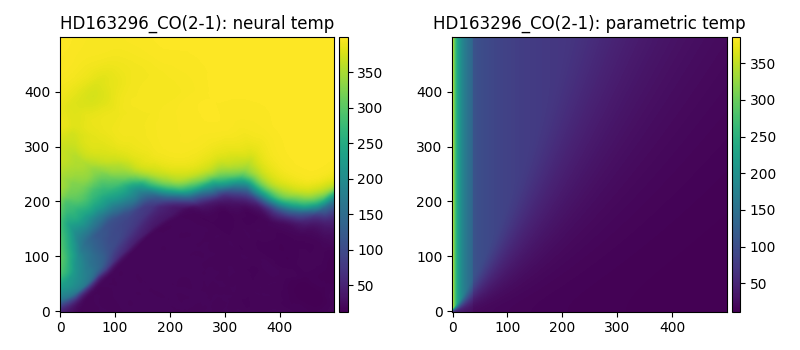

In [11]:
%matplotlib widget
fig, axes = plt.subplots(1, 2, figsize=(8,3.5))
titles = ['{}: neural temp', '{}: parametric temp']
images = [temperature_nn, temperature]
for ax, img, title in zip(axes, images, titles):
    im = ax.imshow(img, origin='lower')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='3%', pad=0.05)
    cbar = fig.colorbar(im, cax=cax)
    ax.set_title(title.format(disk.name))
plt.tight_layout()

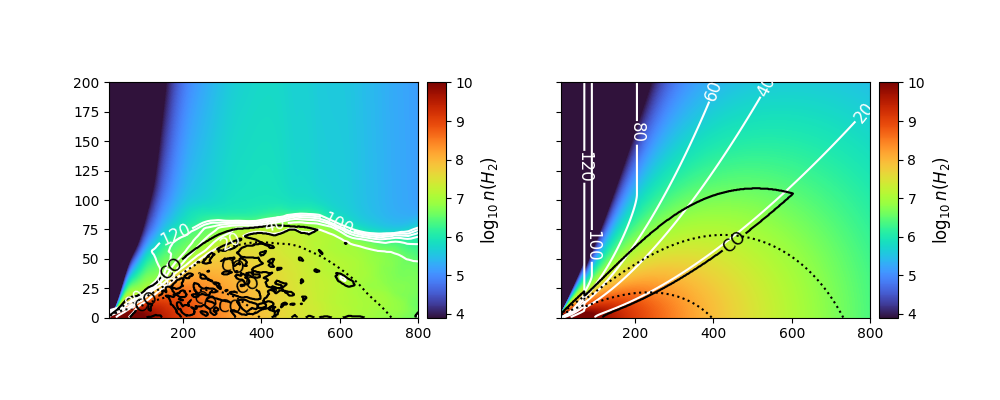

In [12]:
%matplotlib widget
fig, axes = plt.subplots(1,2, figsize=(10,4), sharey=True)
im = axes[0].imshow(np.log10(nd_h2_nn), origin='lower', cmap='turbo', extent=[r_disk.min(), r_disk.max(), z_disk.min(), z_disk.max()], vmin=3.9, vmax=10, aspect=3);
divider = make_axes_locatable(axes[0])
cax = divider.append_axes('right', size='2%', pad=-3)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(r'$\log_{10} n(H_2)$', fontsize=12)

levels = [20, 40, 60, 80, 100, 120]
cp = axes[0].contour(r_disk, z_disk, temperature_nn, levels, colors='white')
axes[0].clabel(cp, levels, inline=1, fontsize=12);
cp = axes[0].contour(r_disk, z_disk, abundance_co_nn, levels=[disk.co_abundance/2], colors='black')
axes[0].clabel(cp, levels=[disk.co_abundance/2], fmt='CO', inline=1, fontsize=12);
cp = axes[0].contour(r_disk, z_disk, sigma_h2_nn, levels=[0.01, 0.1], colors='black', linestyles='dotted')

im = axes[1].imshow(np.log10(nd_h2), origin='lower', cmap='turbo', extent=[r_disk.min(), r_disk.max(), z_disk.min(), z_disk.max()], vmin=3.9, vmax=10, aspect=3);
divider = make_axes_locatable(axes[1])
cax = divider.append_axes('right', size='2%', pad=-3)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(r'$\log_{10} n(H_2)$', fontsize=12)

cp = axes[1].contour(r_disk, z_disk, temperature, levels, colors='white')
axes[1].clabel(cp, levels, inline=1, fontsize=12);
cp = axes[1].contour(r_disk, z_disk, abundance_co, levels=[disk.co_abundance/2], colors='black')
axes[1].clabel(cp, levels=[disk.co_abundance/2], fmt='CO', inline=1, fontsize=12);
cp = axes[1].contour(r_disk, z_disk, sigma_h2, levels=[0.01, 0.1], colors='black', linestyles='dotted')

plt.tight_layout()
fig.subplots_adjust(left=-0.2, wspace=-0.3)

In [31]:
# Render spectral cube and convolve with gaussian beam
# images = render_cube(ray_coords, pixel_area, disk, nd_co, temperature, -velocity_az, bbox_disk, freqs, nu0)
# images_blurred = sensor.fftconvolve_vmap(images, beam)

images_nn = render_cube(ray_coords, pixel_area, disk, nd_co_nn, temperature_nn, -velocity_az_nn, bbox_disk, freqs, nu0)
images_blurred_nn = sensor.fftconvolve_vmap(images_nn, beam)

# Save output cube: the header flips the .fits frequency. I guess its because of the way go-fish loads the data.
# from astropy.io import fits
# out_path = checkpoint_dir.joinpath('spectral_cube_iter30000_blurred.fits')
# fits.writeto(out_path, images_blurred_nn.astype('float32'), data_cube.header)
np.save(checkpoint_dir.joinpath('data_cube_' + hparams['disk_name'] + '.npy'), data)
np.save(checkpoint_dir.joinpath('recovered_cube_iter{}_blurred.npy'.format(ckpt_iter)), images_blurred_nn)

computing spectral cube for a total of 40 frequencies


In [53]:
def slider_frame_comparison(frames1, frames2, axis=0, scale='amp', vmin=None, vmax=None, cmap='viridis'):
    """
    Slider comparison of two 3D xr.DataArray along a chosen dimension.
    Parameters
    ----------
    frames1: xr.DataArray
        A 3D array with 'axis' dimension to compare along
    frames2:  xr.DataArray
        A 3D array with 'axis' dimension to compare along
    scale: 'amp' or 'log', default='amp'
        Compare absolute values or log of the fractional deviation.
    """
    from ipywidgets import interact
    frames1 = np.array(frames1)
    frames2 = np.array(frames2)
    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    plt.tight_layout()
    mean_images = [frames1.mean(axis=axis), frames2.mean(axis=axis),
                   (np.abs(frames1 - frames2)).mean(axis=axis)]
    cbars = []
    titles = [None]*3
    if scale == 'amp':
        titles[2] = 'Absolute difference'
    elif scale == 'log':
        titles[2] = 'Log relative difference'

    for ax, image in zip(axes, mean_images):
        im = ax.imshow(image, origin='lower', cmap=cmap)
        im.set_clim(vmin, vmax)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
        divider = make_axes_locatable(ax)
        cax = divider.append_axes('right', size='5%', pad=0.05)
        cbars.append(fig.colorbar(im, cax=cax))

    def imshow_frame(frame):
        image1 = np.take(frames1, frame, axis=axis)
        image2 = np.take(frames2, frame, axis=axis)

        if scale == 'amp':
            image3 = np.abs(np.take(frames1, frame, axis=axis) - np.take(frames2, frame, axis=axis))
        elif scale == 'log':
            image3 = np.log(np.abs(np.take(frames1, frame, axis=axis) / np.take(frames2, frame, axis=axis)))

        for ax, img, title, cbar in zip(axes, [image1, image2, image3], titles, cbars):
            im = ax.imshow(img, origin='lower', cmap=cmap)
            im.set_clim(vmin, vmax)
            ax.set_title(title)
            cbar.mappable.set_clim([vmin, vmax])

    num_frames = min(frames1.shape[axis], frames2.shape[axis])
    plt.tight_layout()
    interact(imshow_frame, frame=(0, num_frames-1));

interactive(children=(IntSlider(value=19, description='frame', max=39), Output()), _dom_classes=('widget-inter…

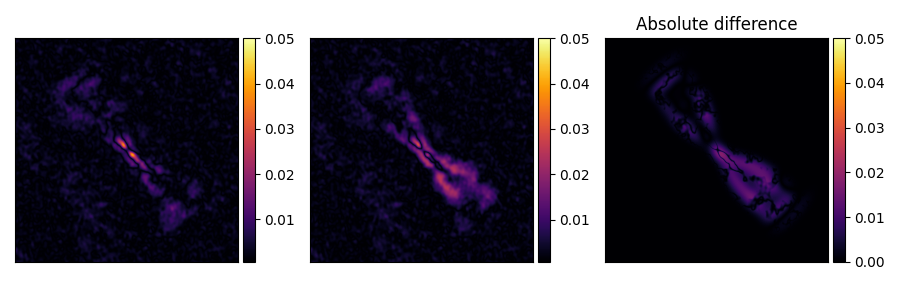

In [55]:
slider_frame_comparison(np.abs(data - images_blurred_nn), np.abs(data - images_blurred), vmax=0.05, cmap='inferno')

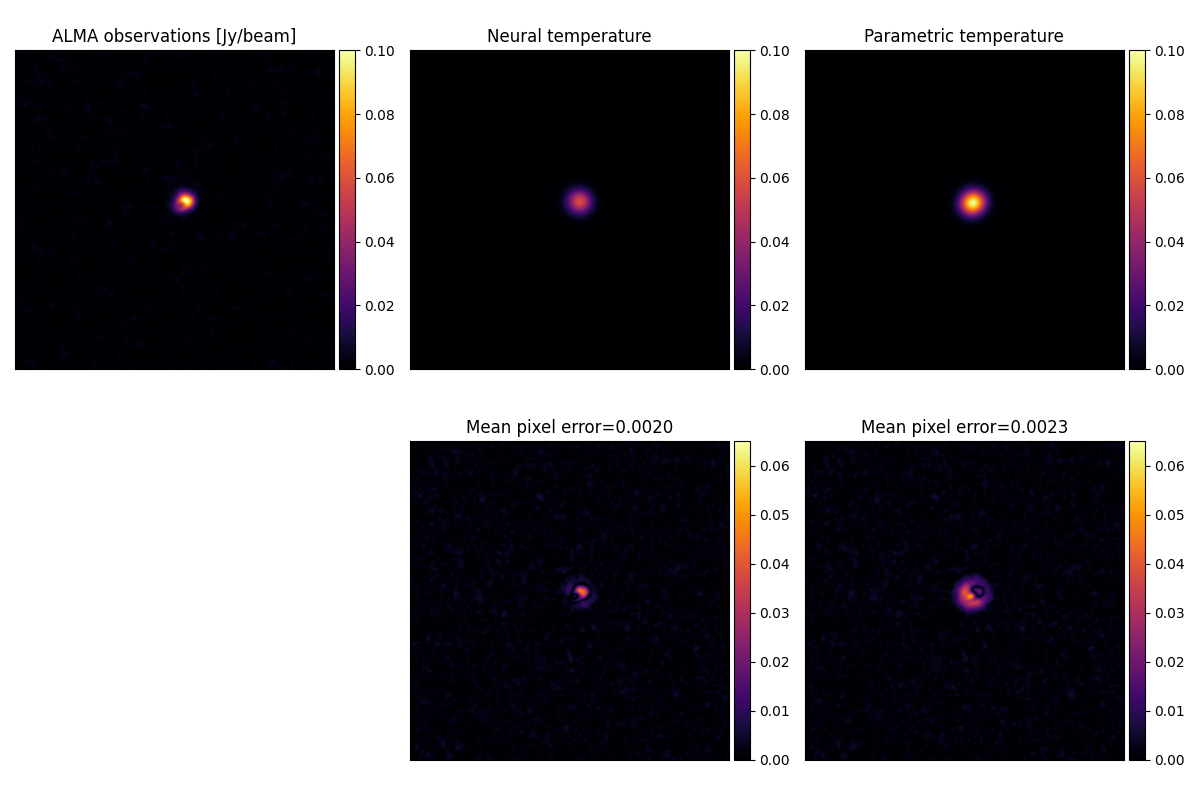

In [41]:
output = checkpoint_dir.joinpath('spectral_cubes_comparison_iter{}.gif'.format(ckpt_iter))

# Save a gif/plot for the data cube for quick visualization
%matplotlib widget
fig, axes = plt.subplots(2,3,figsize=(12,8))
axes[1,0].axis("off")
axes_list = list(axes[0]) + list(axes[1,1:])

data_fit = np.abs(data - images_blurred).mean()
data_fit_nn = np.abs(data - images_blurred_nn).mean()
titles = [r'ALMA observations [Jy/beam]', 'Neural temperature', 'Parametric temperature',
          r'Mean pixel error={:1.4f}'.format(data_fit_nn), r'Mean pixel error={:1.4f}'.format(data_fit)]
movies = [data, np.array(images_blurred_nn), np.array(images_blurred),
         np.abs(data - images_blurred_nn), np.abs(data - images_blurred)]
visualization.animate_movies_synced(
    movies, axes_list, vmin=[0,0,0,0,0,0], vmax=[0.1,0.1,0.1,0.065,0.065], 
    titles=titles, cmaps='inferno', fps=3, writer='ffmpeg', output=output
)

In [ ]:
%matplotlib widget
fig, axes = plt.subplots(1,2, figsize=(10,3), sharey=True)

for ax, nd, temp, abund in zip(axes, [nd_h2, nd_h2_rj], [temperature, temperature_rj], [abundance_co, abundance_co_rj]):
    im = ax.imshow(np.log10(nd), origin='lower', cmap='turbo', extent=[r_disk.min(), r_disk.max(), z_disk.min(), z_disk.max()], vmin=3.9, vmax=10, aspect=3);
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='2%', pad=-2)
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label(r'$\log_{10} n(H_2)$', fontsize=12)

    levels = [20, 40, 60, 80, 100, 120]
    cp = ax.contour(r_disk, z_disk, temp, levels, colors='white')
    ax.clabel(cp, levels, inline=1, fontsize=12);
    cp = ax.contour(r_disk, z_disk, abund, levels=[5e-5], colors='black')
    ax.clabel(cp, levels=[5e-5], fmt='CO', inline=1, fontsize=12);

axes[0].set_title('Flaherty')
axes[1].set_title('Recovered')
plt.tight_layout()

In [ ]:
from IPython.display import display, Math
sigma = 5e-3

num_dof = len(posterior_params)
reduced_chi2_fl = np.mean(((images_blurred_fl - data)/sigma)**2) / num_dof
txt = "\chi^2_{{\mathrm{{Flaherty}}}} = {}"
txt = txt.format(reduced_chi2_fl)
display(Math(txt))

reduced_chi2_rj = np.mean(((images_blurred_rj - data)/sigma)**2) / num_dof
txt = "\chi^2_{{\mathrm{{radjax}}}} = {}"
txt = txt.format(reduced_chi2_rj)
display(Math(txt))